In [21]:
# ============================================================
# SECTION 1 : Imports
# ============================================================

# -------------------------------
# System
# -------------------------------

from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

# -------------------------------
# Data
# -------------------------------

import numpy as np
import pandas as pd

# -------------------------------
# Model
# -------------------------------

import joblib

# -------------------------------
# PDF
# -------------------------------

import fitz

# -------------------------------
# NLP
# -------------------------------

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# Explainable AI
# -------------------------------

from lime.lime_text import LimeTextExplainer

# -------------------------------
# Visualization
# -------------------------------

import matplotlib.pyplot as plt

# -------------------------------
# Display
# -------------------------------

from IPython.display import display

print("="*60)
print("FAIRHIRE")
print("Explainable AI Notebook")
print("="*60)

print("\nLibraries Imported Successfully")

FAIRHIRE
Explainable AI Notebook

Libraries Imported Successfully


In [22]:
# ============================================================
# SECTION 2 : Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

MODELS_DIR = PROJECT_ROOT / "models"

OUTPUT_DIR = PROJECT_ROOT / "outputs"

RESUME_DIR = (
    PROJECT_ROOT
    / "real_test_data"
    / "resumes"
    / "Cloud, DevOps and SRE"
)

JOB_DESCRIPTION_FILE = (
    PROJECT_ROOT
    / "real_test_data"
    / "job_descriptions"
    / "cloud_devops_sre.txt"
)

print("Project Root")
print(PROJECT_ROOT)

print("\nResume Folder")
print(RESUME_DIR)

print("\nJob Description")
print(JOB_DESCRIPTION_FILE)

print("\nOutputs")
print(OUTPUT_DIR)

Project Root
d:\Semesters\6th_Sem + Minor\Minor Project\FairHire

Resume Folder
d:\Semesters\6th_Sem + Minor\Minor Project\FairHire\real_test_data\resumes\Cloud, DevOps and SRE

Job Description
d:\Semesters\6th_Sem + Minor\Minor Project\FairHire\real_test_data\job_descriptions\cloud_devops_sre.txt

Outputs
d:\Semesters\6th_Sem + Minor\Minor Project\FairHire\outputs


In [23]:
# ============================================================
# SECTION 3 : Load Trained Model
# ============================================================

best_model = joblib.load(
    MODELS_DIR / "best_model.pkl"
)

vectorizer = joblib.load(
    MODELS_DIR / "vectorizer.pkl"
)

feature_names = joblib.load(
    MODELS_DIR / "feature_names.pkl"
)

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("="*60)

print("Best Model Loaded")

print(type(best_model))

print("\nVectorizer Loaded")

print("\nTotal Features :", len(feature_names))

print("="*60)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Best Model Loaded
<class 'xgboost.sklearn.XGBClassifier'>

Vectorizer Loaded

Total Features : 156


In [24]:
# ============================================================
# SECTION 4 : Load Candidate Ranking CSV
# ============================================================

csv_files = sorted(
    OUTPUT_DIR.glob("candidate_ranking_*.csv"),
    key=lambda x: x.stat().st_mtime,
    reverse=True
)

if len(csv_files) == 0:

    raise FileNotFoundError(
        "No candidate ranking CSV found."
    )

ranking = pd.read_csv(
    csv_files[0]
)

print("Latest Ranking File")

print(csv_files[0].name)

display(
    ranking[
        [
            "SN",
            "Candidate Name",
            "Decision",
            "Candidate Score"
        ]
    ]
)

Latest Ranking File
candidate_ranking_20260805_131013.csv


,SN,Candidate Name,Decision,Candidate Score
0,1,DevOps-Engineer-Resume,SELECTED,85.87
1,2,Infrastructure-Engineer-Resume,SELECTED,76.86
2,3,Cloud-Engineer-Resume,REJECTED,72.30
3,4,Site-Reliability-Engineer-Resume,REJECTED,66.92
4,5,AWS-Engineer-Resume,REJECTED,64.34
5,6,Platform-Engineer-Resume,REJECTED,57.67
6,7,DevSecOps-Engineer-Resume,REJECTED,56.62
7,8,Azure-Engineer-Resume,REJECTED,52.78


In [25]:
# ============================================================
# SECTION 5 : Select Candidate
# ============================================================

candidate_number = 2

candidate = ranking.loc[
    ranking["SN"] == candidate_number
].iloc[0]

candidate_name = candidate["Candidate Name"]

resume_path = (
    RESUME_DIR
    / f"{candidate_name}.pdf"
)

print("="*60)

print("Candidate Selected")

print(candidate_name)

print("\nResume")

print(resume_path)

print("="*60)

Candidate Selected
Infrastructure-Engineer-Resume

Resume
d:\Semesters\6th_Sem + Minor\Minor Project\FairHire\real_test_data\resumes\Cloud, DevOps and SRE\Infrastructure-Engineer-Resume.pdf


In [26]:
# ============================================================
# SECTION 6 : Read Resume & Job Description
# ============================================================

def extract_text_from_pdf(pdf_path):

    document = fitz.open(pdf_path)

    text = ""

    for page in document:

        text += page.get_text()

    return text


resume_text = extract_text_from_pdf(
    resume_path
)

with open(
    JOB_DESCRIPTION_FILE,
    "r",
    encoding="utf-8"
) as file:

    job_description = file.read()

print("="*60)

print("Resume Characters")

print(len(resume_text))

print("\nJD Characters")

print(len(job_description))

print("="*60)

Resume Characters
4937

JD Characters
1529


In [27]:
# ============================================================
# SECTION 7 : Generate TF-IDF Features
# ============================================================

resume_vector = vectorizer.transform(
    [resume_text]
)

print("="*60)

print("TF-IDF Vector Generated")

print()

print("Shape :", resume_vector.shape)

print("="*60)

TF-IDF Vector Generated

Shape : (1, 156)


In [28]:
# ============================================================
# SECTION 8 : Model Prediction
# ============================================================

prediction = best_model.predict(
    resume_vector
)[0]

probability = (
    best_model.predict_proba(
        resume_vector
    )[0][1]
    * 100
)

print("="*60)

print("Model Prediction")

print()

print("Prediction :", prediction)

print(f"Probability : {probability:.2f}%")

print("="*60)

Model Prediction

Prediction : 0
Probability : 17.32%


In [29]:
# ============================================================
# SECTION 9 : Load Candidate Metrics
# ============================================================

print("=" * 60)
print("Candidate Metrics")
print("=" * 60)

matched_count = int(candidate["Matched Count"])
missing_count = int(candidate["Missing Count"])
skill_match = (
    matched_count /
    (matched_count + missing_count)
) * 100 if (matched_count + missing_count) > 0 else 0

candidate_metrics = {

    "Candidate Name": candidate["Candidate Name"],

    "Decision": candidate["Decision"],

    "Candidate Score": float(candidate["Candidate Score"]),

    "Selection Probability": float(candidate["Selection Probability"]),

    "Keyword Coverage": float(candidate["Keyword Coverage"]),

    "Semantic Similarity": float(candidate["Semantic Similarity"]),

    "Experience Match": float(candidate["Experience Score"]),

    "Skill Match": skill_match,

    "Matched Count": matched_count,

    "Missing Count": missing_count,

    "Matched Skills": candidate["Matched Skills"],

    "Missing Skills": candidate["Missing Skills"]

}

for key, value in candidate_metrics.items():

    print(f"{key:<25}: {value}")

Candidate Metrics
Candidate Name           : Infrastructure-Engineer-Resume
Decision                 : SELECTED
Candidate Score          : 76.86
Selection Probability    : 2.92
Keyword Coverage         : 77.42
Semantic Similarity      : 0.7667
Experience Match         : 100.0
Skill Match              : 77.41935483870968
Matched Count            : 24
Missing Count            : 7
Matched Skills           : ['agile', 'ansible', 'automation', 'aws', 'azure', 'bash', 'cloud', 'cloudformation', 'docker', 'gcp', 'github', 'grafana', 'helm', 'iam', 'jenkins', 'kubernetes', 'linux', 'monitoring', 'networking', 'prometheus', 'python', 'security', 'terraform', 'vpc']
Missing Skills           : ['cloud security', 'cloudwatch', 'communication', 'devops', 'docker kubernetes', 'git', 'git github']


In [30]:
# Normalize Matched/Missing skills (handle CSV string representations)
import ast

def _to_list(val):
    if isinstance(val, list):
        return val
    if not isinstance(val, str):
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return parsed
    except Exception:
        pass
    # fallback: comma-separated
    if "," in val:
        return [x.strip() for x in val.split(",") if x.strip()]
    return [val] if val else []

# Update candidate_metrics in-place
if 'Matched Skills' in candidate_metrics:
    candidate_metrics['Matched Skills'] = _to_list(candidate_metrics['Matched Skills'])
if 'Missing Skills' in candidate_metrics:
    candidate_metrics['Missing Skills'] = _to_list(candidate_metrics['Missing Skills'])

# Ensure counts are consistent
candidate_metrics['Matched Count'] = int(candidate_metrics.get('Matched Count', len(candidate_metrics.get('Matched Skills', []))))
candidate_metrics['Missing Count'] = int(candidate_metrics.get('Missing Count', len(candidate_metrics.get('Missing Skills', []))))

print('Normalized Matched/ Missing skills counts:', candidate_metrics['Matched Count'], candidate_metrics['Missing Count'])

Normalized Matched/ Missing skills counts: 24 7


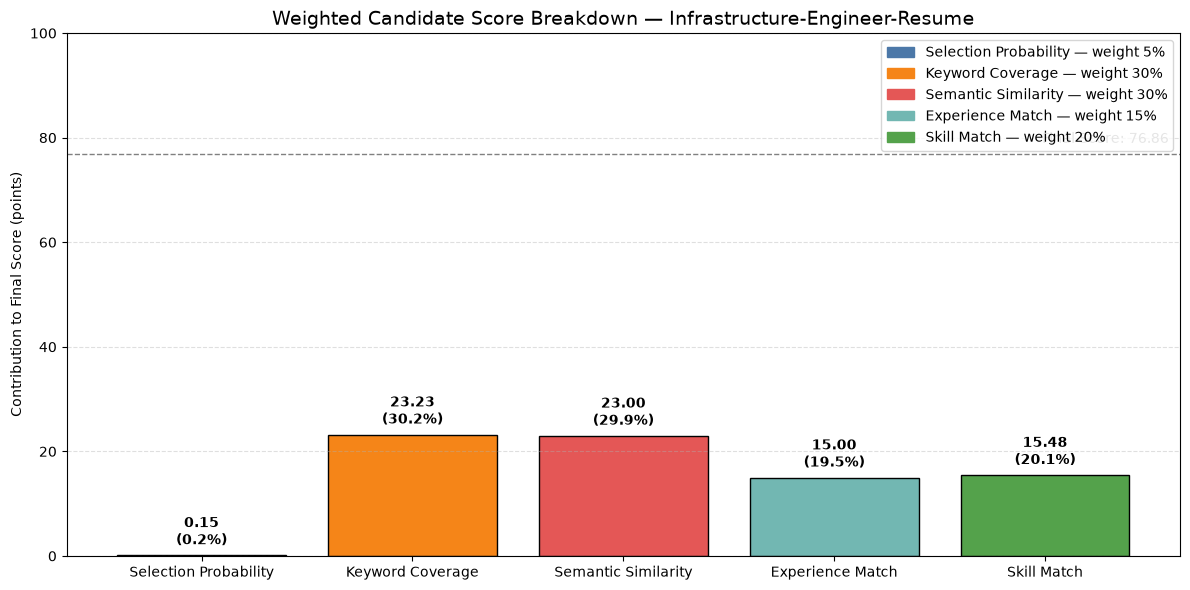


Final Candidate Score : 76.86
Saved plot to: d:\Semesters\6th_Sem + Minor\Minor Project\FairHire\outputs\weighted_breakdown_Infrastructure-Engineer-Resume.png
Saved breakdown CSV to: d:\Semesters\6th_Sem + Minor\Minor Project\FairHire\outputs\weighted_breakdown_Infrastructure-Engineer-Resume.csv


,component,value,weight,weighted_contribution,pct_of_final
0,Selection Probability,2.920,0.05,0.146,0.190
1,Keyword Coverage,77.420,0.30,23.226,30.220
2,Semantic Similarity,76.670,0.30,23.001,29.927
3,Experience Match,100.000,0.15,15.000,19.517
4,Skill Match,77.419,0.20,15.484,20.146


In [31]:
# ============================================================
# SECTION 10 : Candidate Score Breakdown (Enhanced + Export)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ------------------------------------------------------------
# Values used in Candidate Score
# ------------------------------------------------------------
components = [
    "Selection Probability",
    "Keyword Coverage",
    "Semantic Similarity",
    "Experience Match",
    "Skill Match"
]

# ------------------------------------------------------------
# Weighted contribution to the final score
# ------------------------------------------------------------
weights = [0.05, 0.30, 0.30, 0.15, 0.20]
values = [
    candidate_metrics["Selection Probability"],
    candidate_metrics["Keyword Coverage"],
    candidate_metrics["Semantic Similarity"] * 100,
    candidate_metrics["Experience Match"],
    candidate_metrics["Skill Match"]
]

weighted_contributions = [value * weight for value, weight in zip(values, weights)]

# Total check (should equal candidate final score within rounding)
total_contribution = sum(weighted_contributions)
candidate_score = candidate_metrics["Candidate Score"]

# Per-component percentage of the final score
contrib_pct = [wc / total_contribution * 100 if total_contribution > 0 else 0 for wc in weighted_contributions]

# ------------------------------------------------------------
# Create tidy DataFrame for export and display
# ------------------------------------------------------------
df_breakdown = pd.DataFrame({
    "component": components,
    "value": values,
    "weight": weights,
    "weighted_contribution": weighted_contributions,
    "pct_of_final": contrib_pct
})

# Round numeric columns for readability
for col in ["value", "weight", "weighted_contribution", "pct_of_final"]:
    df_breakdown[col] = df_breakdown[col].round(3)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ["#4C78A8", "#F58518", "#E45756", "#72B7B2", "#54A24B"]

bars = ax.bar(df_breakdown['component'], df_breakdown['weighted_contribution'], color=bar_colors, edgecolor="black")

ax.set_title(f"Weighted Candidate Score Breakdown — {candidate_metrics['Candidate Name']}", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Contribution to Final Score (points)")
ax.set_ylim(0, max(100, candidate_score + 10))
ax.grid(axis="y", linestyle='--', alpha=0.4)

# Annotate each bar with value and percent of final
for bar, row in zip(bars, df_breakdown.itertuples(index=False)):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    ax.text(x, y + 1.2, f"{row.weighted_contribution:.2f}\n({row.pct_of_final:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Horizontal line for the final candidate score
ax.axhline(candidate_score, color='gray', linestyle='--', linewidth=1)
ax.text(0.99, candidate_score + 1.5, f"Final Score: {candidate_score:.2f}", ha='right', va='bottom', transform=ax.get_yaxis_transform(), fontsize=10, color='gray')

# Legend showing weight mapping
legend_patches = [mpatches.Patch(color=bar_colors[i], label=f"{components[i]} — weight {int(weights[i]*100)}%") for i in range(len(weights))]
ax.legend(handles=legend_patches, loc='upper right')

plt.tight_layout()

# Ensure outputs folder exists and save
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
img_name = f"weighted_breakdown_{candidate_metrics['Candidate Name'].replace(' ', '_')}.png"
img_path = OUTPUT_DIR / img_name
fig.savefig(img_path, bbox_inches='tight', dpi=150)

# Export CSV of breakdown
csv_name = f"weighted_breakdown_{candidate_metrics['Candidate Name'].replace(' ', '_')}.csv"
csv_path = OUTPUT_DIR / csv_name
df_breakdown.to_csv(csv_path, index=False)

# Display
plt.show()
print()
print(f"Final Candidate Score : {candidate_score:.2f}")
print(f"Saved plot to: {img_path}")
print(f"Saved breakdown CSV to: {csv_path}")

# Show the tidy table
display(df_breakdown)

In [32]:
# ============================================================
# SECTION 11 : Prepare LIME Explainer
# ============================================================

from lime.lime_text import LimeTextExplainer

# ------------------------------------------------------------
# Prediction Function
# ------------------------------------------------------------

def lime_predict(texts):

    tfidf = vectorizer.transform(texts)

    probs = best_model.predict_proba(tfidf)

    return probs

# ------------------------------------------------------------
# Class Names
# ------------------------------------------------------------

class_names = [

    "Rejected",

    "Selected"

]

# ------------------------------------------------------------
# LIME Explainer
# ------------------------------------------------------------

explainer = LimeTextExplainer(

    class_names=class_names,

    split_expression=r"\W+",

    bow=True

)

print("=" * 60)

print("LIME Explainer Initialized")

print()

print("Classes :")

print(class_names)

print("=" * 60)

LIME Explainer Initialized

Classes :
['Rejected', 'Selected']


In [33]:
# ============================================================
# SECTION 12 : Generate LIME Explanation
# ============================================================

print("="*60)
print("Generating LIME Explanation...")
print("="*60)

# ------------------------------------------------------------
# Candidate text
# ------------------------------------------------------------

candidate_text = candidate_metrics.get("Resume Text", resume_text)

# ------------------------------------------------------------
# Generate Explanation
# ------------------------------------------------------------

lime_exp = explainer.explain_instance(

    candidate_text,

    lime_predict,

    labels=(0,1),

    num_features=15

)

# ------------------------------------------------------------
# Predicted Label
# ------------------------------------------------------------

prediction_probability = lime_predict([candidate_text])[0]

reject_prob = prediction_probability[0] * 100

select_prob = prediction_probability[1] * 100

predicted_label = int(np.argmax(prediction_probability))

predicted_class = class_names[predicted_label]

print("="*60)

print("ML Model Prediction")

print("="*60)

print(f"Rejected Probability : {reject_prob:.2f}%")

print(f"Selected Probability : {select_prob:.2f}%")

print()

print(f"Predicted Class : {predicted_class}")

print("="*60)

print("LIME Explanation Generated Successfully")

Generating LIME Explanation...
ML Model Prediction
Rejected Probability : 82.68%
Selected Probability : 17.32%

Predicted Class : Rejected
LIME Explanation Generated Successfully


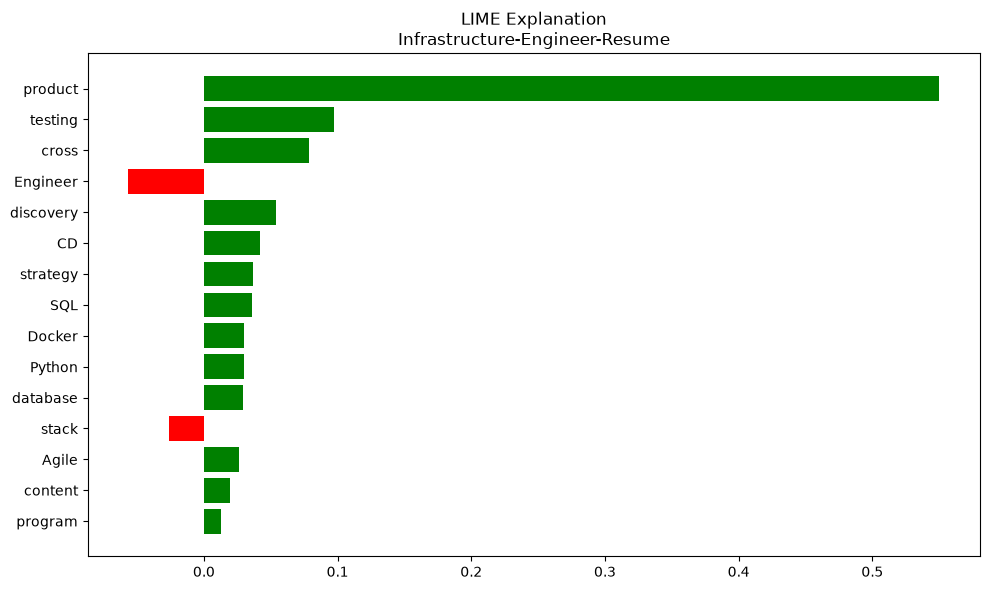

In [34]:
# ============================================================
# SECTION 13 : LIME Feature Importance
# ============================================================

import matplotlib.pyplot as plt

fig = lime_exp.as_pyplot_figure(
    label=predicted_label
)

fig.set_size_inches(10,6)

plt.title(
    f"LIME Explanation\n{candidate_metrics['Candidate Name']}"
)

plt.tight_layout()

plt.show()

In [35]:
# ============================================================
# SECTION 14 : Top Positive & Negative Features
# ============================================================

lime_features = lime_exp.as_list(
    label=predicted_label
)

lime_df = pd.DataFrame(
    lime_features,
    columns=[
        "Feature",
        "Weight"
    ]
)

positive_df = (
    lime_df
    [lime_df["Weight"]>0]
    .sort_values(
        "Weight",
        ascending=False
    )
)

negative_df = (
    lime_df
    [lime_df["Weight"]<0]
    .sort_values(
        "Weight"
    )
)

print("="*60)

print("TOP POSITIVE FEATURES")

print("="*60)

display(positive_df)
print()

print("="*60)

print("TOP NEGATIVE FEATURES")

print("="*60)

display(negative_df)

TOP POSITIVE FEATURES


,Feature,Weight
0,product,0.550206
1,testing,0.097145
2,cross,0.078392
4,discovery,0.054278
5,CD,0.041685
6,strategy,0.036747
7,SQL,0.035753
8,Docker,0.029721
9,Python,0.029664
10,database,0.029106



TOP NEGATIVE FEATURES


,Feature,Weight
3,Engineer,-0.056558
11,stack,-0.026429


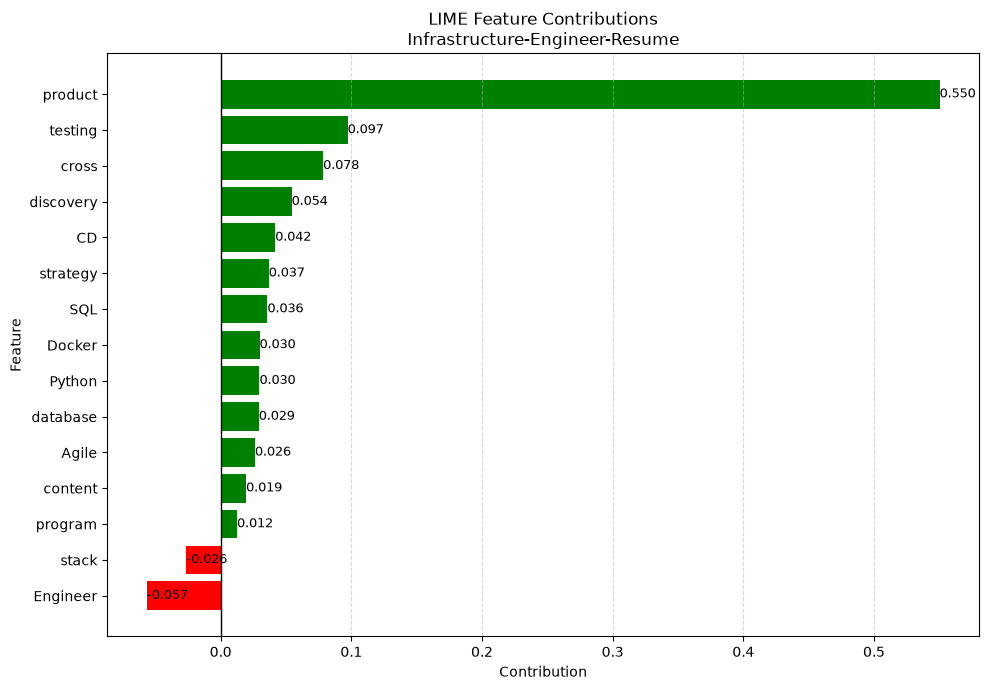

In [36]:
# ============================================================
# SECTION 15 : Feature Contribution Waterfall
# ============================================================

import matplotlib.pyplot as plt

plot_df = lime_df.copy()
plot_df = plot_df.sort_values(
    "Weight"
)

colors = [
    "red"
    if w<0
    else "green"
    for w in plot_df["Weight"]
]

plt.figure(
    figsize=(10,7)
)

bars = plt.barh(
    plot_df["Feature"],
    plot_df["Weight"],
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.xlabel(
    "Contribution"
)

plt.ylabel(
    "Feature"
)

plt.title(
    f"LIME Feature Contributions\n{candidate_metrics['Candidate Name']}"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

In [37]:
# ============================================================
# SECTION 16 : Explainability Report
# ============================================================

from IPython.display import display

# ------------------------------------------------------------
# Top Positive Features
# ------------------------------------------------------------

top_positive = (
    positive_df
    .head(5)["Feature"]
    .tolist()
)

# ------------------------------------------------------------
# Top Negative Features
# ------------------------------------------------------------

top_negative = (
    negative_df
    .head(5)["Feature"]
    .tolist()
)

# ------------------------------------------------------------
# Create Report Dictionary
# ------------------------------------------------------------

report = {
    "Candidate Name":
        candidate_metrics["Candidate Name"],

    "Final Decision":
        candidate_metrics["Decision"],

    "Candidate Score":
        round(candidate_metrics["Candidate Score"],2),

    "Selection Probability":
        f"{candidate_metrics['Selection Probability']:.2f}%",

    "Keyword Coverage":
        f"{candidate_metrics['Keyword Coverage']:.2f}%",

    "Semantic Similarity":
        round(candidate_metrics["Semantic Similarity"],3),

    "Experience Match":
        f"{candidate_metrics['Experience Match']:.2f}%",

    "Skill Match":
        f"{candidate_metrics['Skill Match']:.2f}%",

    "Matched Skills":
        len(candidate_metrics["Matched Skills"]),

    "Missing Skills":
        len(candidate_metrics["Missing Skills"]),

    "Top Positive Features":
        ", ".join(top_positive),

    "Top Negative Features":
        ", ".join(top_negative)

}

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

report_df = pd.DataFrame(
    report.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

print("="*70)

print("FAIRHIRE EXPLAINABILITY REPORT")

print("="*70)

display(report_df)

FAIRHIRE EXPLAINABILITY REPORT


,Metric,Value
0,Candidate Name,Infrastructure-Engineer-Resume
1,Final Decision,SELECTED
2,Candidate Score,76.86
3,Selection Probability,2.92%
4,Keyword Coverage,77.42%
5,Semantic Similarity,0.767
6,Experience Match,100.00%
7,Skill Match,77.42%
8,Matched Skills,24
9,Missing Skills,7


In [38]:
# ============================================================
# SECTION 16B : Console Summary
# ============================================================

print("\n")

print("="*70)

print("FAIRHIRE EXPLAINABILITY REPORT")

print("="*70)

print(f"Candidate Name         : {candidate_metrics['Candidate Name']}")
print(f"Candidate Score        : {candidate_metrics['Candidate Score']:.2f}")
print(f"Final Decision         : {candidate_metrics['Decision']}")

print("-"*70)

print(f"Selection Probability  : {candidate_metrics['Selection Probability']:.2f}%")
print(f"Keyword Coverage       : {candidate_metrics['Keyword Coverage']:.2f}%")
print(f"Semantic Similarity    : {candidate_metrics['Semantic Similarity']:.3f}")
print(f"Experience Match       : {candidate_metrics['Experience Match']:.2f}%")
print(f"Skill Match            : {candidate_metrics['Skill Match']:.2f}%")

print("-"*70)

print(f"Matched Skills         : {len(candidate_metrics['Matched Skills'])}")
print(f"Missing Skills         : {len(candidate_metrics['Missing Skills'])}")

print("-"*70)

print("Top Positive Features")
for item in top_positive:
    print(f"  ✓ {item}")
print()

print("Top Negative Features")
for item in top_negative:
    print(f"  ✗ {item}")
    
print("="*70)



FAIRHIRE EXPLAINABILITY REPORT
Candidate Name         : Infrastructure-Engineer-Resume
Candidate Score        : 76.86
Final Decision         : SELECTED
----------------------------------------------------------------------
Selection Probability  : 2.92%
Keyword Coverage       : 77.42%
Semantic Similarity    : 0.767
Experience Match       : 100.00%
Skill Match            : 77.42%
----------------------------------------------------------------------
Matched Skills         : 24
Missing Skills         : 7
----------------------------------------------------------------------
Top Positive Features
  ✓ product
  ✓ testing
  ✓ cross
  ✓ discovery
  ✓ CD

Top Negative Features
  ✗ Engineer
  ✗ stack
